# Detection2: incomplete labels and learned objects

Start here. The active setup has **no precomputed PSF dependency**.

The first runnable experiment compares the current background loss with a loss that leaves plausible unlabelled candidates unknown. Both arms keep the same VIS+NISP seed labels and frozen ten-band representation.

A learned object-to-image decoder prototype is also available, but it is **not yet trained or connected to the first experiment**. Read `../DESIGN.md` for that architecture proposal.

A four-tile proposal pilot and ten-band gallery are already saved locally. Opening this notebook starts nothing. Training cells below are explicit, foreground commands; run them individually after reviewing the setup.

**Active run update:** the user approved increasing the budget from 4 to 12 epochs. Both arms were restarted from the same initial VIS+NISP head, with a 12-epoch cosine schedule, while reusing the already-prepared labels. Previous logs are retained under the original output directory.

- [Control, GPU 0 — 12 epochs](https://wandb.ai/AI-Astro/JAISP-Detection-Q1/runs/mfviwjw1)
- [Unknown regions, GPU 1 — 12 epochs](https://wandb.ai/AI-Astro/JAISP-Detection-Q1/runs/rj1onedv)

Both are in the `detection2-12ep` window of the existing `detection2` screen. **Do not run the launch cells again while these jobs are active.**

[Live comparison report](https://wandb.ai/AI-Astro/JAISP-Detection-Q1/reports/Detection2-detection-progress--VmlldzoxNzkzOTM5NQ==): four validation percentage plots with the starting-model reference, plus threshold tradeoff curves at the latest shared epoch. The CPU monitor runs in screen window `detection2-monitor`. See `../monitoring/README.md` for code, local previews and restart commands.


In [ ]:
from pathlib import Path
import json, os, signal, subprocess, sys
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'models/detection2').is_dir())
BASE = ROOT / 'models/detection2'
CONFIG = BASE / 'configs/unknown_regions_v1.json'
PILOT = BASE / 'runs/pilot_dl_20260915'
STUDY = BASE / 'runs/unknown_regions_20260915_v1_12ep'  # use a new name for a repeat
cfg = json.loads(CONFIG.read_text())
sys.path.insert(0, str(ROOT))
print('Workspace:', BASE)
print('W&B:', f"https://wandb.ai/{cfg['wandb']['entity']}/{cfg['wandb']['project']}")
print('Group:', cfg['wandb']['group'])
display(pd.Series({k: cfg[k] for k in ['initial_checkpoint', 'epochs', 'batch_size', 'lr',
                                      'proposal_floor', 'ignore_radius_vis_px', 'validation_tiles']}))

## Existing local pilot

The pilot uses four training tiles and cannot be used for full training. Candidate status means distance from the existing seed labels; it does not establish whether a source is real or MER-matched.

,tile_id,seeds,proposals,unknown_candidates,ignored_fraction
0,tile_x00000_y00000_tract5063_patch_14,440,530,158,0.010445
1,tile_x01024_y00256_tract5063_patch_15,391,492,125,0.008344
2,tile_x01792_y02560_tract5063_patch_4,378,488,133,0.008743
3,tile_x02816_y02816_tract5063_patch_5,379,460,88,0.005819


504 unlabelled candidate positions; mean ignored area 0.83%


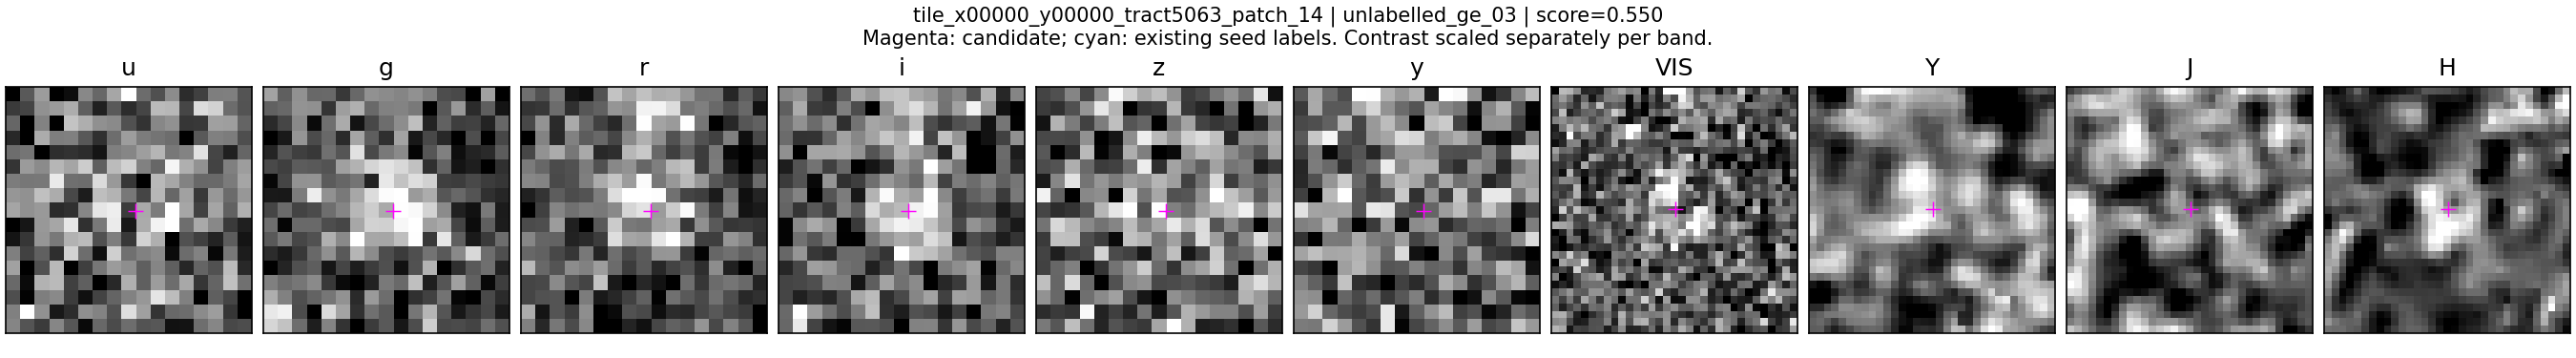

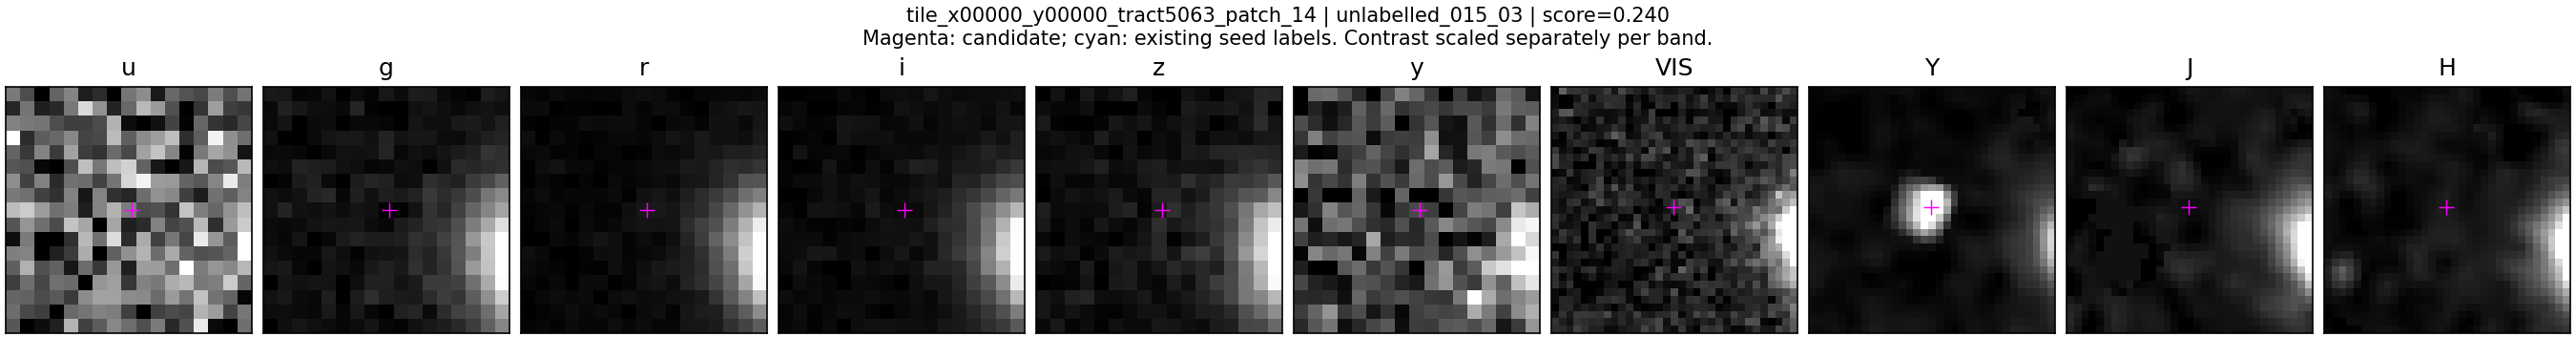

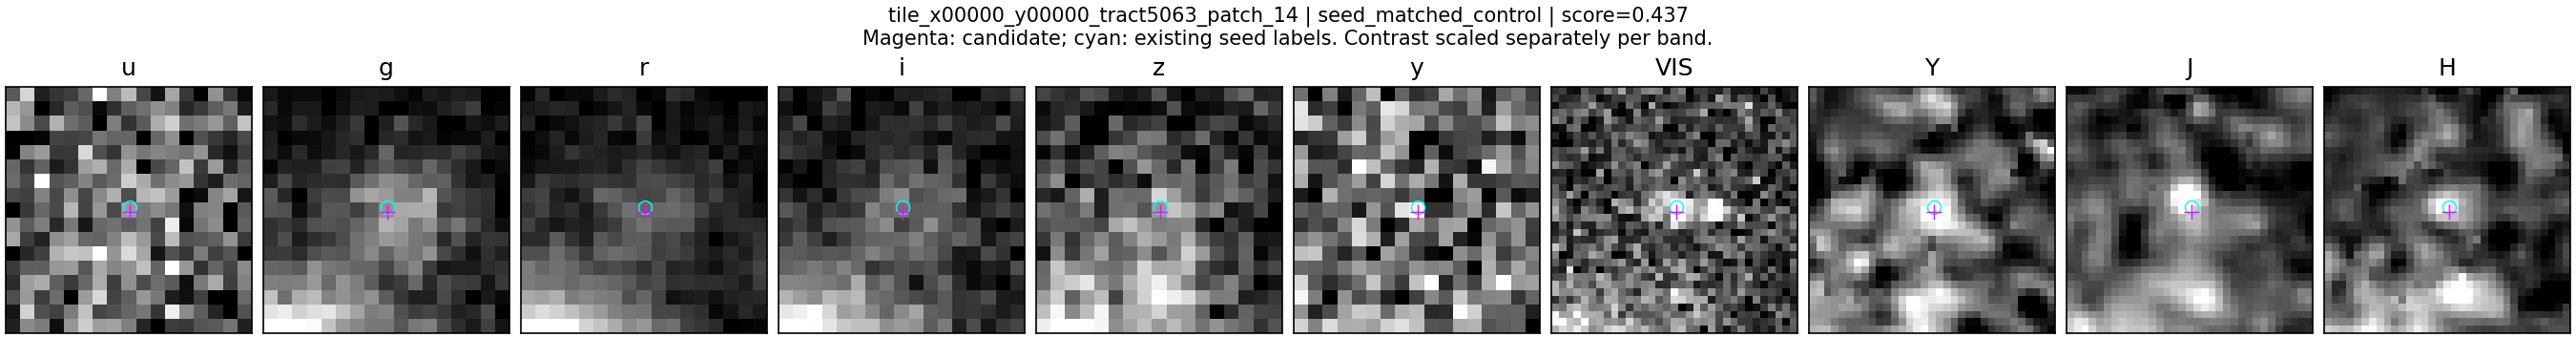

In [2]:
summary = json.loads((PILOT / 'prepared/summary.json').read_text())
display(pd.DataFrame(summary['tiles']))
print(f"{summary['n_unknown']} unlabelled candidate positions; mean ignored area {summary['mean_ignored_fraction']:.2%}")
records = json.loads((PILOT / 'gallery/records.json').read_text())
examples = [next(r for r in records if r['group'] == group) for group in
            ['unlabelled_ge_03', 'unlabelled_015_03', 'seed_matched_control']]
for row in examples:
    display(Image(filename=str(PILOT / 'gallery' / row['gallery'])))

## What is implemented

| Component | Status |
|---|---|
| Fixed teacher proposals, immutable seed labels, unknown masks | Runnable and checked |
| Paired control / unknown-loss training | Running: 12 epochs per arm |
| Online W&B losses and VIS/NIR/full-MER monitoring | Live; see control/unknown run links below |
| Ten-band candidate gallery | Local, no PSF fitting or image uploads |
| Learned object-to-image decoder | Untrained prototype; structural tests pass |
| Masked reconstruction, object birth/death, learned verification | Proposed next architecture experiment |

The twelve patch-25 monitoring tiles are fixed and excluded from head training. They are development data already examined in earlier work. Final-epoch selection is fixed in advance; EDF-S is not used during training. MER match fraction is a catalogue-agreement metric, not absolute source purity.

In [3]:
check = json.loads((PILOT / 'execution_check/check.json').read_text())
print('GPU check: weight updates =', check['weight_updates'])
display(pd.Series(check['losses']))
from models.detection2.object_decoder import LearnedObjectDecoder
renderer = LearnedObjectDecoder()
print('Learned renderer parameters:', sum(p.numel() for p in renderer.parameters()))
print('Renderer status: untrained; no PSF checkpoint or image bypass.')

GPU check: weight updates = 0


loss_hm                 0.643653
loss_off                0.429316
loss_flux               0.000000
loss_total              1.072968
n_sources             385.000000
mean_source_weight      1.000000
dtype: float64

Learned renderer parameters: 43179
Renderer status: untrained; no PSF checkpoint or image bypass.


## Foreground launcher

Every command is printed, streamed into this notebook, and saved to `STUDY/launch_logs/`. Interrupting the cell also interrupts its child process. Existing output directories are never overwritten. W&B initialization must succeed before optimizer updates begin. Only training metrics/configuration are sent to W&B; cutouts and model checkpoints stay local.

In [ ]:
def launch(module, arguments, label):
    command = [sys.executable, '-u', '-m', module, *map(str, arguments)]
    print('Command:', subprocess.list2cmdline(command), flush=True)
    log_dir = STUDY / 'launch_logs'
    log_dir.mkdir(parents=True, exist_ok=True)
    env = dict(os.environ)
    env['MPLCONFIGDIR'] = str(STUDY / 'matplotlib_cache')
    with (log_dir / f'{label}.log').open('x', buffering=1) as log:
        with subprocess.Popen(command, cwd=ROOT, env=env, stdout=subprocess.PIPE,
                              stderr=subprocess.STDOUT, text=True, bufsize=1) as proc:
            try:
                for line in proc.stdout:
                    print(line, end='', flush=True)
                    log.write(line)
                rc = proc.wait()
            except KeyboardInterrupt:
                proc.send_signal(signal.SIGINT)
                try:
                    proc.wait(timeout=15)
                except subprocess.TimeoutExpired:
                    proc.kill()
                    proc.wait()
                raise
            if rc:
                raise RuntimeError(f'{label} exited with code {rc}; see {log_dir}')

PREPARED = BASE / 'runs/unknown_regions_20260915_v1/prepared'  # reuse the complete frozen proposals
CONTROL = STUDY / 'control'
UNKNOWN = STUDY / 'unknown'
DEVICE = 'cuda:0' 

## 1. Prepare all training tiles — no optimizer updates

Run once after reviewing the configuration. This freezes proposals for all 682 training tiles before either arm trains. It uses the fixed teacher and saves every seed/proposal coordinate locally.

In [ ]:
if (PREPARED / 'labels.pt').exists():
    print('Reusing completed proposal preparation:', PREPARED)
else:
    launch('models.detection2.prepare', ['--config', CONFIG, '--out', PREPARED, '--device', DEVICE], 'prepare')

## 2. Control training — explicit launch

Twelve epochs from the same VIS+NISP checkpoint, keeping the existing background loss. The W&B run URL is printed at initialization and saved under `control/wandb_run.json`.

In [ ]:
launch('models.detection2.train', ['--prepared', PREPARED, '--out', CONTROL, '--arm', 'control', '--device', DEVICE, '--epochs', cfg['epochs']], 'control')

## 3. Unknown-region training — explicit launch

Same initialization, seeds, data order and training budget. Only the negative loss inside the frozen unknown masks changes. These cells run sequentially in one kernel. Parallel runs can use separate terminals/kernels and GPU devices with the same printed commands.

In [ ]:
launch('models.detection2.train', ['--prepared', PREPARED, '--out', UNKNOWN, '--arm', 'unknown', '--device', DEVICE, '--epochs', cfg['epochs']], 'unknown')

## 4. Compare monitoring curves

Loss values differ by construction because the unknown arm omits some negative terms. Compare completeness and MER agreement together. Do not select whichever threshold/epoch looks best and present it as the fixed comparison.

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
for arm, folder in [('control', CONTROL), ('unknown', UNKNOWN)]:
    history = folder / 'history.jsonl'
    if not history.exists():
        print(f'{arm}: not started')
        continue
    link = json.loads((folder / 'wandb_run.json').read_text())['url']
    display(Markdown(f'[{arm}: live W&B]({link})'))
    rows = pd.read_json(history, lines=True)
    train = rows.dropna(subset=['train/loss'])
    axes[0].plot(train['train/step'], train['train/loss'], label=arm, alpha=.7)
    vals = sorted(folder.glob('validation_epoch_*.json'))
    epochs = [int(p.stem.rsplit('_', 1)[1]) for p in vals]
    metrics = [json.loads(p.read_text())['metrics'] for p in vals]
    axes[1].plot(epochs, [m['val/t0.30/nir_only_completeness'] for m in metrics], 'o-', label=arm)
    axes[2].plot(epochs, [m['val/t0.30/mer_match_fraction'] for m in metrics], 'o-', label=arm)
for ax, title, xlabel in zip(axes, ['Training loss', 'NIR-only completeness at 0.30', 'MER match fraction at 0.30'], ['Step', 'Epoch', 'Epoch']):
    ax.set_title(title); ax.set_xlabel(xlabel)
    if ax.lines: ax.legend()
plt.show()

## 5. Final evaluation — explicit launch after both runs finish

Compare the starting VIS+NISP head and both final heads on all patch-25 tiles and EDF-S using the existing evaluator. This can take longer because EDF-S requires foundation inference. Outputs remain under this experiment. These are catalogue comparisons; paired injections/deeper references are subsequent checks.

In [ ]:
launch('models.detection.visnir_eval_experiment', [
    '--checkpoint', f"initial={ROOT / cfg['initial_checkpoint']}",
    '--checkpoint', f'control={CONTROL / "final.pt"}',
    '--checkpoint', f'unknown={UNKNOWN / "final.pt"}',
    '--out', STUDY / 'final_evaluation', '--field', 'both', '--device', DEVICE
], 'final_evaluation')

## Next: learning the object decoder

The prototype is `../object_decoder.py`; the staged proposal is `../DESIGN.md`.

Its input is an explicit object set: positions, presence gates and compact appearance vectors. A shared neural network with band embeddings learns the rendered appearance. There are no precomputed PSFs. Masked reconstruction must mask pixels **before** feature encoding; the current full-image feature cache cannot establish held-out-pixel prediction. Learning object count and preventing objects from absorbing neighbours remain separate design and validation steps.